In [2]:
# Project: Solar Panel Requirement to Charge a Smartphone Daily

"""
Can a solar panel reliably charge your phone every day?
How many panels are needed based on weather conditions and location?

This notebook will:
- Estimate daily phone charging energy needs
- Calculate solar panel producation based on wattage, sunlight hours, and efficiency
- Compare regions and seasons
- Visualize energy production vs. energy demand
"""

'\nCan a solar panel reliably charge your phone every day?\nHow many panels are needed based on weather conditions and location?\n\nThis notebook will:\n- Estimate daily phone charging energy needs\n- Calculate solar panel producation based on wattage, sunlight hours, and efficiency\n- Compare regions and seasons\n- Visualize energy production vs. energy demand\n'

In [3]:
import urllib.request
import json
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
# Energy needed to fully charge a smartphone (Wh)
phone_energy_wh = {
    "iPhone 14": 12.7,
    "Samsung Galaxy S23": 15.0,
    "Pixel 7": 13.0
}

phone_energy_wh

{'iPhone 14': 12.7, 'Samsung Galaxy S23': 15.0, 'Pixel 7': 13.0}

In [4]:
def solar_energy_output(panel_wattage, sunlight_hours, efficiency_loss_percent):
    """
    Calculates daily energy output from a solar panel.

    panel_wattage: Watts (W)
    sunlight_hours: Effective sun hours per day
    efficiency_loss_percent: e.g., 25 means 25% loss
    """
    raw_output = panel_wattage * sunlight_hours
    net_output = raw_output * (1 - efficiency_loss_percent / 100)
    return net_output

In [5]:
regions = {
    "California": {"sunlight_hours": 6, "efficiency_loss": 25},
    "Northern Europe": {"sunlight_hours": 3, "efficiency_loss": 30}
}

panel_wattage = 10

for region, data in regions.items():
    output = solar_energy_output(panel_wattage, data["sunlight_hours"], data["efficiency_loss"])
    print(f"{region}: {output:.2f} Wh/day with a {panel_wattage}W panel")


California: 45.00 Wh/day with a 10W panel
Northern Europe: 21.00 Wh/day with a 10W panel


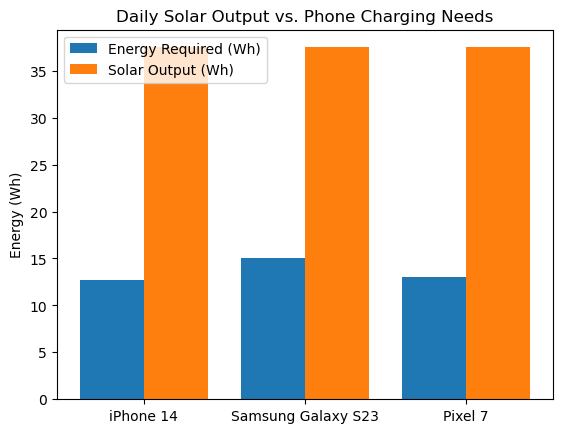

In [6]:
import matplotlib.pyplot as plt

phones = list(phone_energy_wh.keys())
energy_required = list(phone_energy_wh.values())
solar_output = [solar_energy_output(10, 5, 25)] * len(phones)

x = range(len(phones))
plt.bar(x, energy_required, width=0.4, label='Energy Required (Wh)', align='center')
plt.bar([i + 0.4 for i in x], solar_output, width=0.4, label='Solar Output (Wh)', align='center')
plt.xticks([i + 0.2 for i in x], phones)
plt.ylabel("Energy (Wh)")
plt.title("Daily Solar Output vs. Phone Charging Needs")
plt.legend()
plt.show()


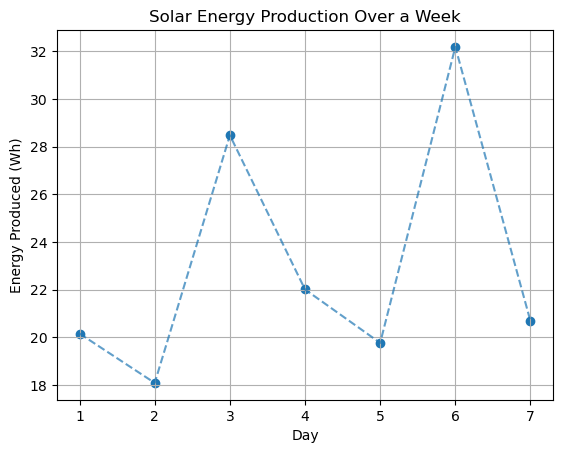

In [7]:
import numpy as np
days = np.arange(1, 8)
sunlight = np.random.uniform(2, 6, size=7)  # Simulated daily sun hours
daily_output = [solar_energy_output(10, hrs, 25) for hrs in sunlight]

plt.scatter(days, daily_output)
plt.plot(days, daily_output, linestyle='--', alpha=0.7)
plt.title("Solar Energy Production Over a Week")
plt.xlabel("Day")
plt.ylabel("Energy Produced (Wh)")
plt.grid(True)
plt.show()


In [8]:
# Real locations to compare
locations = {
    "Los Angeles": (34.0522, -118.2437),
    "Oslo": (59.9139, 10.7522)
}

# API fetch function
def fetch_solar_data(lat, lon):
    start_date = datetime.now().strftime("%Y-%m-%d")
    end_date = (datetime.now() + timedelta(days=7)).strftime("%Y-%m-%d")
    url = f'https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/{lat},{lon}/{start_date}/{end_date}?unitGroup=metric&elements=datetimeEpoch,solarradiation&key=298LYYNTAZVEU5JN67C8W5AQE&contentType=json'
    response = urllib.request.urlopen(url).read()
    return json.loads(response)

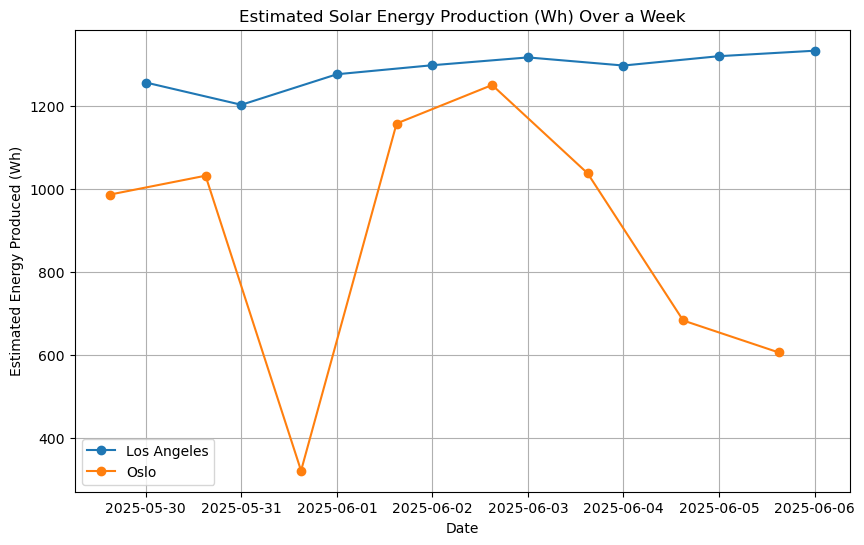

In [9]:
# Store results
solar_data = {}

# Collect and convert data
for city, (lat, lon) in locations.items():
    data = fetch_solar_data(lat, lon)
    records = data['days']
    df = pd.DataFrame([{
        'Date': datetime.fromtimestamp(day['datetimeEpoch']),
        'SolarRadiation (W/m²)': day.get('solarradiation', 0)
    } for day in records])
    df['Estimated Wh'] = df['SolarRadiation (W/m²)'] * 1.0 * 5 * 0.75  # 1m², 5 hours, 75% efficiency
    solar_data[city] = df

# Plot results
plt.figure(figsize=(10, 6))
for city, df in solar_data.items():
    plt.plot(df['Date'], df['Estimated Wh'], marker='o', label=city)

plt.title("Estimated Solar Energy Production (Wh) Over a Week")
plt.xlabel("Date")
plt.ylabel("Estimated Energy Produced (Wh)")
plt.legend()
plt.grid(True)
plt.show()
